<a href="https://colab.research.google.com/github/isabellaschen/Exploratory-Data-Analysis---Yahoo-Finance/blob/main/Finance_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Overarching study questions**:

*Primary:* To what extent do company fundamentals explain stock returns, price, and risk?

*Secondary:* To what extent does company performance correlate with CEO salary?

In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import yfinance as yf

In [79]:
# Access 1y stock close data
  # It's more efficient to download stock data rather than including it in the loop
tickers = ['ZM','PLTR','NVDA','MSFT','AAPL','CRM','ORCL',
           'META','GOOGL','CMCSA','NFLX','VZ',
           'AMZN','TSLA','F','MCD','NKE','GM','SBUX',
           'JBLU','LMT','BA','GE','UPS',
           'WMT','KO','TGT','COST','PG',
           'UNH','JNJ','PFE','CVS','MRK',
           'BLK','V','MA','PYPL'
           ]
data_hist = yf.download(tickers, period='1y', interval='1d')['Close']

# Calculate stock return over the past year
stock_returns = ((data_hist.iloc[-1] - data_hist.iloc[0]) / data_hist.iloc[0]).to_dict()

# Dictionary of sectors and associated companies
companies = {
    'Technology':['ZM','PLTR','NVDA','MSFT', 'AAPL','CRM','ORCL'],
    'Communication Services':['META','GOOGL','CMCSA','NFLX','VZ'],
    'Consumer Cyclical':['AMZN','TSLA','F','MCD','NKE','GM','SBUX'],
    'Industrials':['JBLU','LMT','BA','GE','UPS'],
    'Consumer Staples':['WMT','KO','TGT','COST','PG'],
    'Healthcare':['UNH','JNJ','PFE','CVS','MRK'],
    'Financial Services':['BLK','V','MA','PYPL']
    }

data = []

# Primary loop to get data on each company
for sector, tickers in companies.items():

  for company in tickers:
    ticker_object = yf.Ticker(company)

  # Basic Info
    company_name = ticker_object.info['longName']
    company_sector = ticker_object.info['sector']

    # CEO Pay - not all companies have reported pay for CEO
    position = ticker_object.info['companyOfficers'][0]
    title = position['title']
    name = position['name']
    if 'totalPay' in position:
      pay = position['totalPay']
    else:
      pay = 'Unknown'

  # Company Fundamentals
    mk_cap = ticker_object.info['marketCap']
    eps = ticker_object.income_stmt.iloc[:,0].loc['Basic EPS']
    # roe = (ticker_object.income_stmt.loc['Net Income'] / ticker_object.income_stmt.loc['Stockholders Equity'])

    total_debt = ticker_object.info['totalDebt']
    debt_ratio = total_debt / mk_cap

    current_price = ticker_object.info['currentPrice']
    pe = current_price / eps

    revenue_growth = (ticker_object.info['revenueGrowth'])*100
    profit_margin = ticker_object.info['profitMargins']
    ebitda_margins = ticker_object.info['ebitdaMargins']

    # Liquidity Ratios
    quick_ratio = ticker_object.info['quickRatio']
    current_ratio = ticker_object.info['currentRatio']
    # current_assets = ticker_object.balance_sheet.loc['Current Assets'].iloc[0]
    # current_liabilities = ticker_object.balance_sheet.loc['Current Liabilities'].iloc[0]

  # Technical
    beta = ticker_object.info['beta']

  # Stock Return and Price
    stock_return = stock_returns.get(company)
    tg_price = ticker_object.info['targetMeanPrice']
    price_growth = ((tg_price - current_price)/current_price)*100

  # Construct a new dataset
    data.append({
        'Company':company_name,
        'Sector':company_sector,
        'CEO Name':name,
        'CEO Pay':pay,
        'Stock Return':stock_return,
        'Beta':beta,
        'Current Price':current_price,
        'Target Price':tg_price,
        'Predicted Price Growth':price_growth,
        'Earnings per Share':eps,
        'P/E Ratio':pe,
        'Profit Margin':profit_margin,
        'EBITDA Margin':ebitda_margins,
        'Revenue Growth':revenue_growth,
        #'Return on Equity':roe,
        'Debt Ratio':debt_ratio,
        'Current':current_ratio,
        'Quick':quick_ratio,
        })

data = pd.DataFrame(data)

/tmp/ipykernel_1643/586550180.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_hist = yf.download(tickers, period='1y', interval='1d')['Close']
[*********************100%***********************]  38 of 38 completed


In [80]:
data

,Company,Sector,CEO Name,CEO Pay,Stock Return,Beta,Current Price,Target Price,Predicted Price Growth,Earnings per Share,P/E Ratio,Profit Margin,EBITDA Margin,Revenue Growth,Debt Ratio,Current,Quick
0,"Zoom Communications, Inc.",Technology,Mr. Eric S. Yuan,2464481,0.038349,0.971,77.71,97.33333,25.252001,6.320000,12.295886,0.39027,0.26180,5.3,0.002541,4.331,4.159
1,Palantir Technologies Inc.,Technology,Mr. Peter Andreas Thiel J.D.,Unknown,0.666395,1.739,143.06,186.60307,30.436929,0.690000,207.333333,0.36310,0.32179,70.0,0.000670,7.110,6.992
2,NVIDIA Corporation,Technology,Mr. Jen-Hsun Huang,11054945,0.527852,2.375,167.52,268.22195,60.113389,4.930000,33.979716,0.55603,0.61698,73.2,0.002803,3.905,3.141
3,Microsoft Corporation,Technology,Mr. Satya Nadella,12251294,-0.050947,1.108,356.77,589.90470,65.345937,13.700000,26.041606,0.39044,0.57377,16.7,0.046491,1.386,1.239
4,Apple Inc.,Technology,Mr. Timothy D. Cook,16759518,0.146785,1.116,248.80,295.31342,18.695105,7.490000,33.217623,0.27037,0.35100,15.7,0.024751,0.974,0.845
5,"Salesforce, Inc.",Technology,Mr. Marc R. Benioff,9646000,-0.331479,1.307,179.31,273.85170,52.725280,7.850000,22.842038,0.17958,0.30218,12.1,0.105414,0.760,0.644
6,Oracle Corporation,Technology,Mr. Lawrence J. Ellison,5643948,0.001457,1.648,139.66,246.45872,76.470514,4.460000,31.313901,0.25298,0.42826,21.7,0.403728,1.347,1.224
7,"Meta Platforms, Inc.",Communication Services,Mr. Mark Elliot Zuckerberg,27219874,-0.085619,1.279,525.72,862.59600,64.078977,NaN,NaN,0.30084,0.50701,23.8,0.063978,2.599,2.423
8,Alphabet Inc.,Communication Services,Mr. Sundar Pichai,10319413,0.783783,1.112,274.34,376.75394,37.331027,10.910000,25.145738,0.32810,0.37279,18.0,0.020187,2.005,1.847
9,Comcast Corporation,Communication Services,Mr. Brian L. Roberts,10200486,-0.140545,0.780,28.33,32.78409,15.722167,5.548507,5.105878,0.16166,0.29812,1.2,1.017451,0.882,0.697


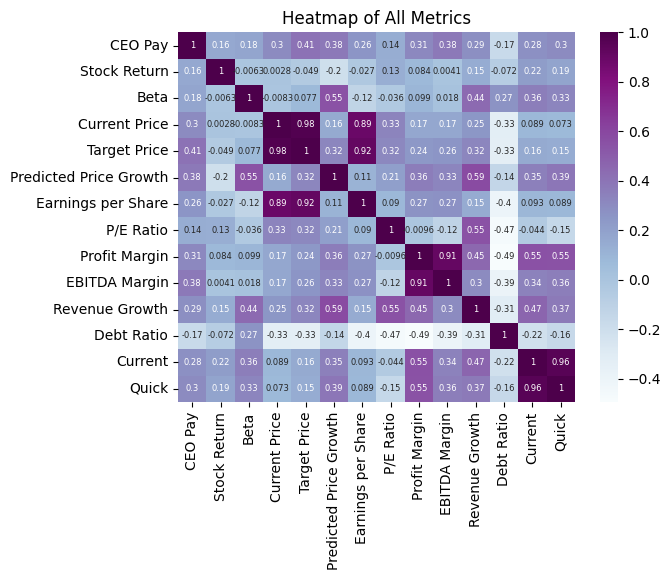

<Figure size 1000x1000 with 0 Axes>

In [99]:
# Heatmap of all data
data = data[data['CEO Pay'] != 'Unknown']
data.loc[:, 'CEO Pay'] = data['CEO Pay'].astype(float)

corr = data.corr(numeric_only = True)
sns.heatmap(corr, annot = True, annot_kws={"size": 6}, cmap = 'BuPu')
plt.title('Heatmap of All Metrics')
plt.figure(figsize=(10, 10))
plt.show()

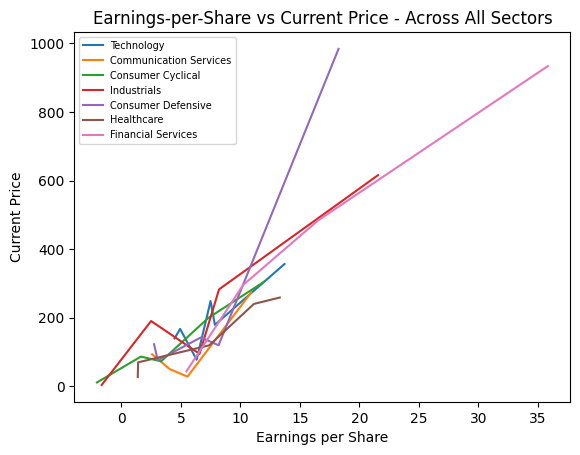

In [82]:
# Strongest Linear Relationship - Earnings per Share vs Current Price
sns.lineplot(data = data, x = 'Earnings per Share', y = 'Current Price', hue = 'Sector')
plt.title('Earnings-per-Share vs Current Price - Across All Sectors')
plt.legend(fontsize = 7)
plt.show()

**Analysis by Sector**

Some quick visualizations to get a clearer look at the dynamics between sectors before proceeding

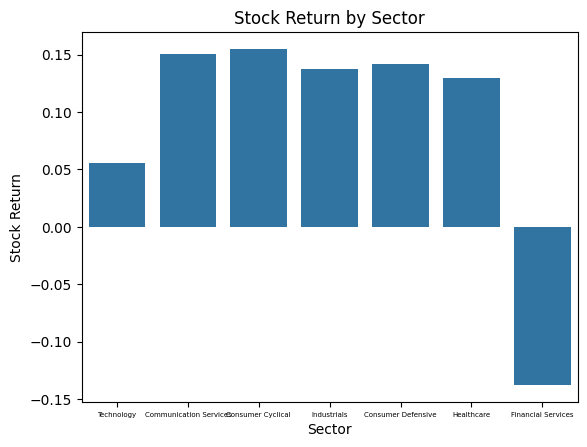

In [83]:
# Stock Return by Sector
sns.barplot(data = data, x = 'Sector', y = 'Stock Return', errorbar = None)
plt.title('Stock Return by Sector')
plt.xticks(fontsize = 5)
plt.show()

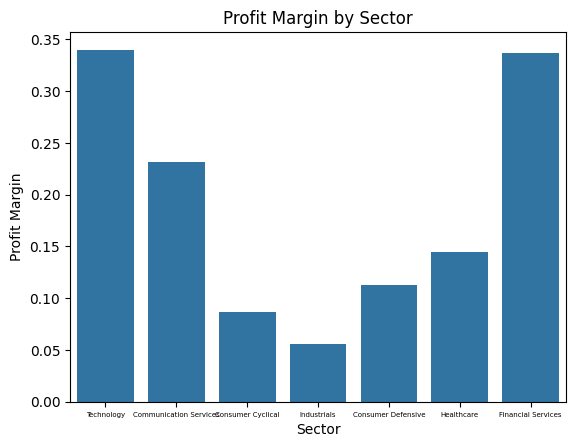

In [84]:
# Profit Margin by Sector
sns.barplot(data = data, x = 'Sector', y = 'Profit Margin', errorbar = None)
plt.title('Profit Margin by Sector')
plt.xticks(fontsize = 5)
plt.show()

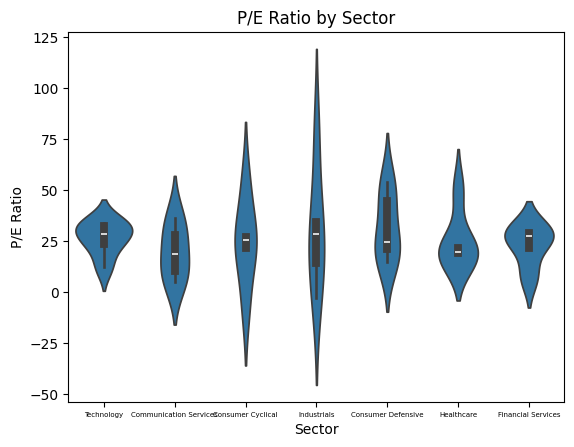

In [85]:
# P/E Ratio by Sector
sns.violinplot(data = data, x = 'Sector', y = 'P/E Ratio')
plt.title('P/E Ratio by Sector')
plt.xticks(fontsize = 5)
plt.show()

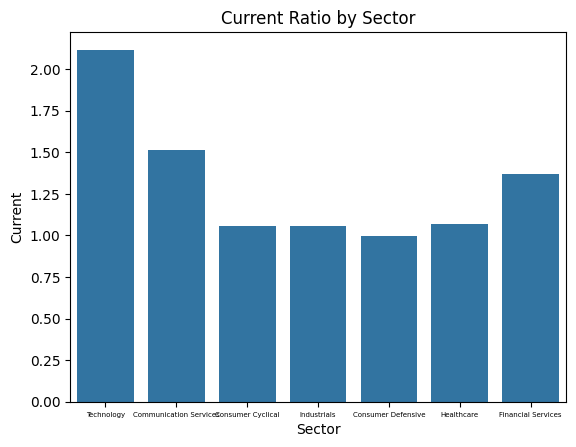

In [86]:
# Current Ratio by Sector
sns.barplot(data = data, x = 'Sector', y = 'Current', errorbar = None)
plt.title('Current Ratio by Sector')
plt.xticks(fontsize = 5)
plt.show()

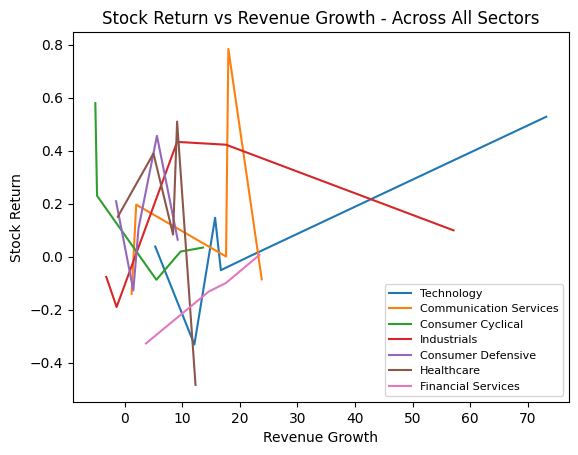

In [87]:
# Stock Return vs Revenue Growth
sns.lineplot(data = data, x = 'Revenue Growth', y = 'Stock Return', hue = 'Sector')
plt.title('Stock Return vs Revenue Growth - Across All Sectors')
plt.legend(fontsize = 8)
plt.show()

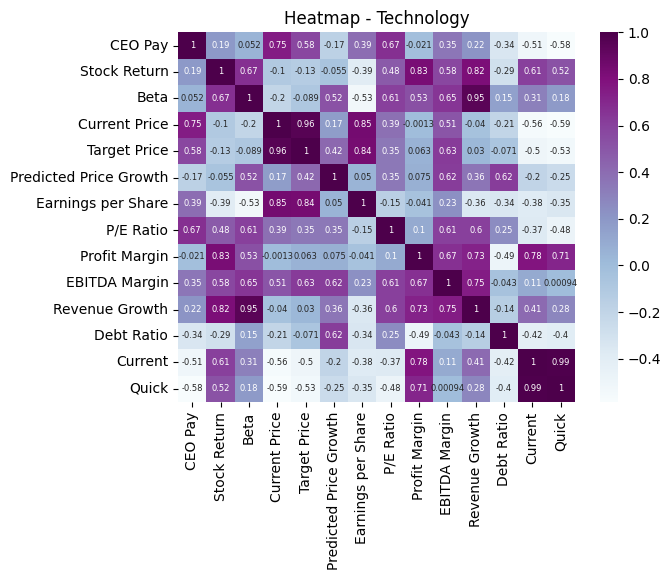

<Figure size 800x800 with 0 Axes>

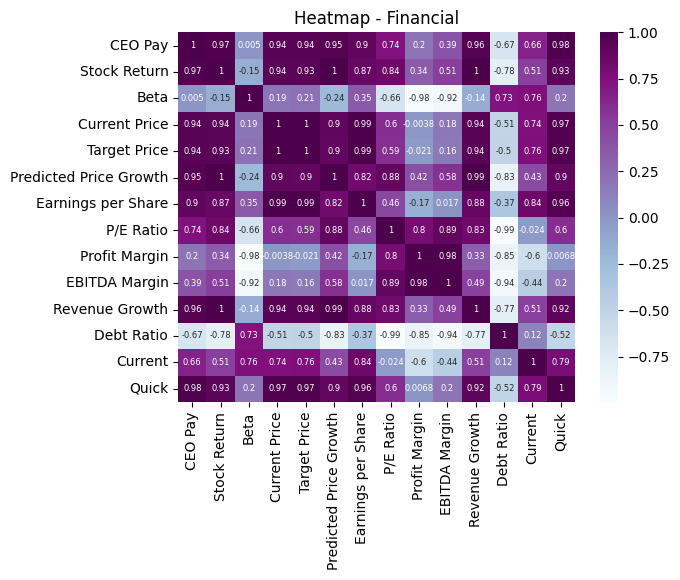

<Figure size 800x800 with 0 Axes>

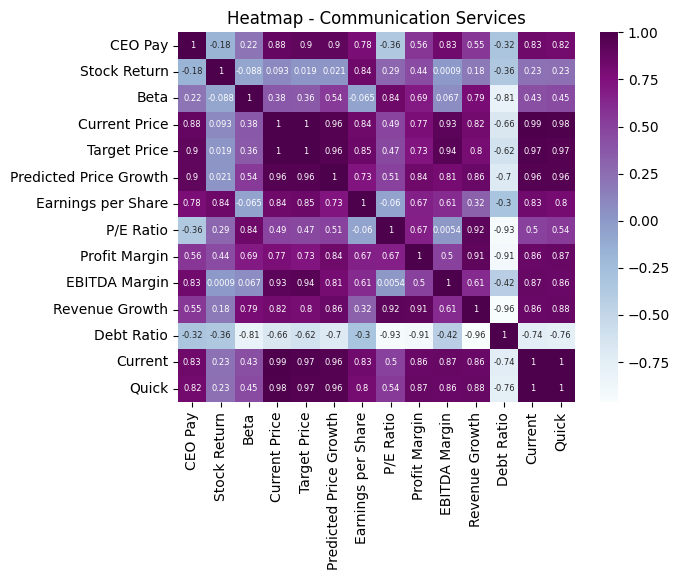

<Figure size 800x800 with 0 Axes>

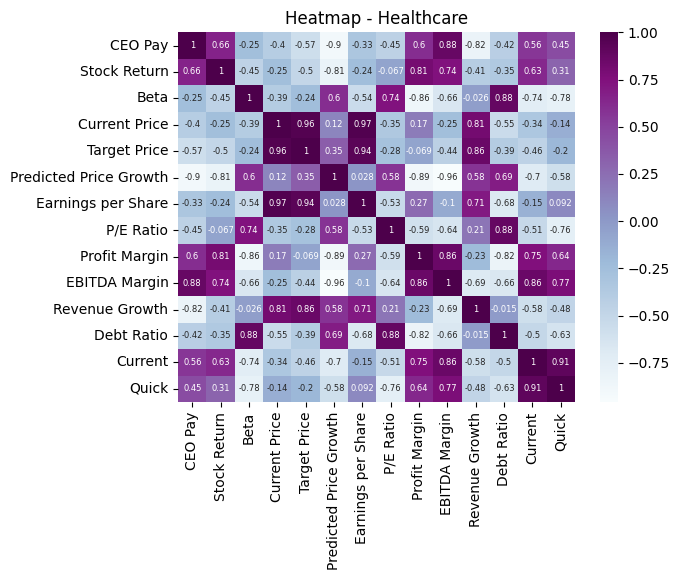

<Figure size 800x800 with 0 Axes>

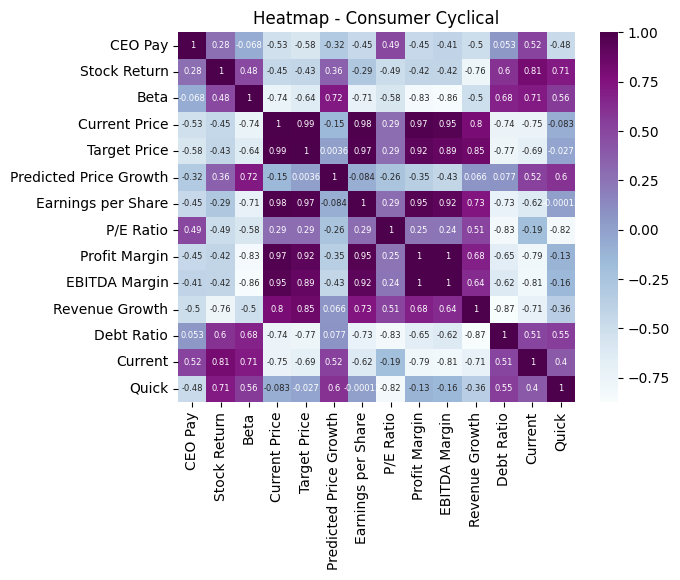

<Figure size 800x800 with 0 Axes>

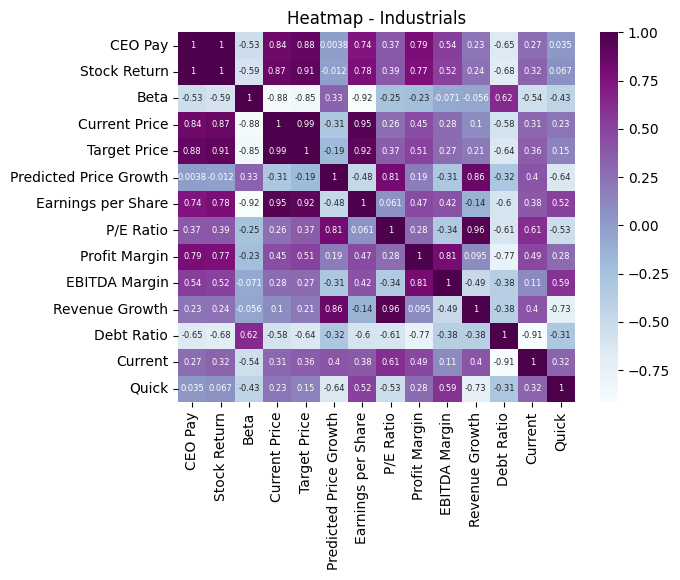

<Figure size 800x800 with 0 Axes>

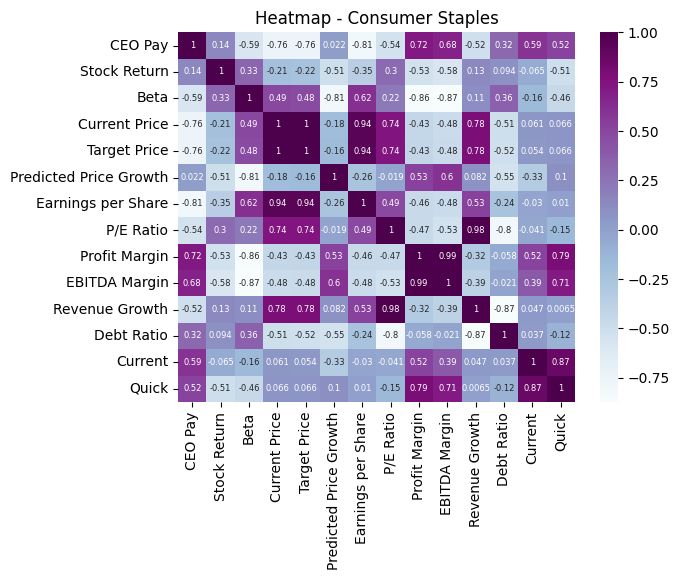

<Figure size 800x800 with 0 Axes>

In [88]:
# Separate Data by Sector

# Technology
tech_data = data.loc[data['Sector'] == 'Technology']

tech_corr = tech_data.corr(numeric_only = True)
sns.heatmap(tech_corr, annot = True, annot_kws={"size": 6}, cmap = 'BuPu')
plt.title('Heatmap - Technology')
plt.figure(figsize=(8, 8))
plt.show()


# Financial Services
fin_data = data.loc[data['Sector'] == 'Financial Services']

fin_corr = fin_data.corr(numeric_only = True)
sns.heatmap(fin_corr, annot = True, annot_kws={"size": 6}, cmap = 'BuPu')
plt.title('Heatmap - Financial')
plt.figure(figsize=(8, 8))
plt.show()


# Communication Services
comm_data = data.loc[data['Sector'] == 'Communication Services']

comm_corr = comm_data.corr(numeric_only = True)
sns.heatmap(comm_corr, annot = True, annot_kws={"size": 6}, cmap = 'BuPu')
plt.title('Heatmap - Communication Services')
plt.figure(figsize=(8, 8))
plt.show()


# Healthcare
health_data = data.loc[data['Sector'] == 'Healthcare']

health_corr = health_data.corr(numeric_only = True)
sns.heatmap(health_corr, annot = True, annot_kws={"size": 6}, cmap = 'BuPu')
plt.title('Heatmap - Healthcare')
plt.figure(figsize=(8, 8))
plt.show()


# Consumer Cyclical
cc_data = data.loc[data['Sector'] == 'Consumer Cyclical']

cc_corr = cc_data.corr(numeric_only = True)
sns.heatmap(cc_corr, annot = True, annot_kws={"size": 6}, cmap = 'BuPu')
plt.title('Heatmap - Consumer Cyclical')
plt.figure(figsize=(8, 8))
plt.show()


# Industrials
ind_data = data.loc[data['Sector'] == 'Industrials']

ind_corr = ind_data.corr(numeric_only = True)
sns.heatmap(ind_corr, annot = True, annot_kws={"size": 6}, cmap = 'BuPu')
plt.title('Heatmap - Industrials')
plt.figure(figsize=(8, 8))
plt.show()

# Consumer Staples
cs_data = data.loc[data['Sector'] == 'Consumer Defensive']

cs_corr = cs_data.corr(numeric_only = True)
sns.heatmap(cs_corr, annot = True, annot_kws={"size": 6}, cmap = 'BuPu')
plt.title('Heatmap - Consumer Staples')
plt.figure(figsize=(8, 8))
plt.show()

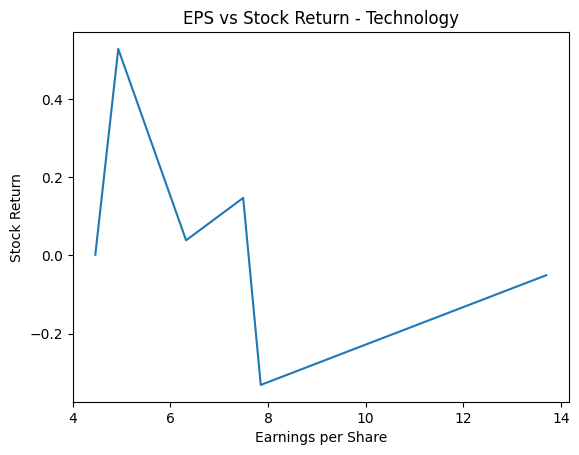

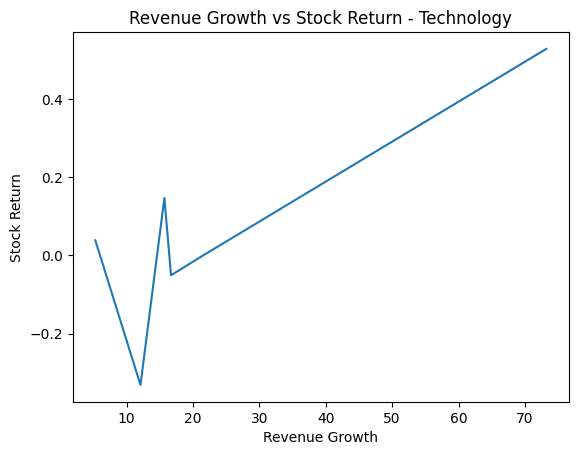

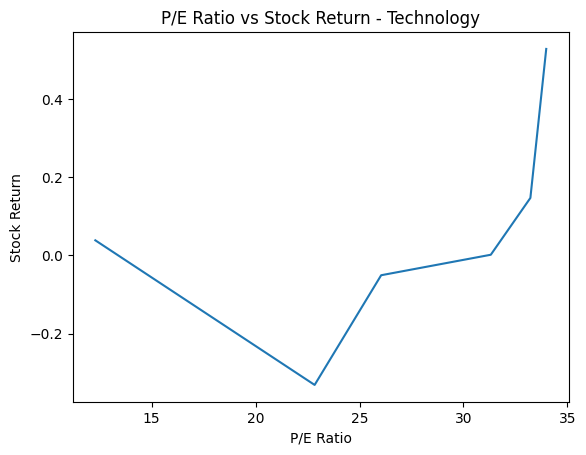

In [90]:
# Technology - Stock Return, EPS, Revenue Growth, P/E Ratio
sns.lineplot(data = tech_data, x = 'Revenue Growth', y = 'Stock Return')
plt.title('Revenue Growth vs Stock Return - Technology')
plt.show()

sns.lineplot(data = tech_data, x = 'Earnings per Share', y = 'Stock Return')
plt.title('EPS vs Stock Return - Technology')
plt.show()

sns.lineplot(data = tech_data, x = 'P/E Ratio', y = 'Stock Return')
plt.title('P/E Ratio vs Stock Return - Technology')
plt.show()

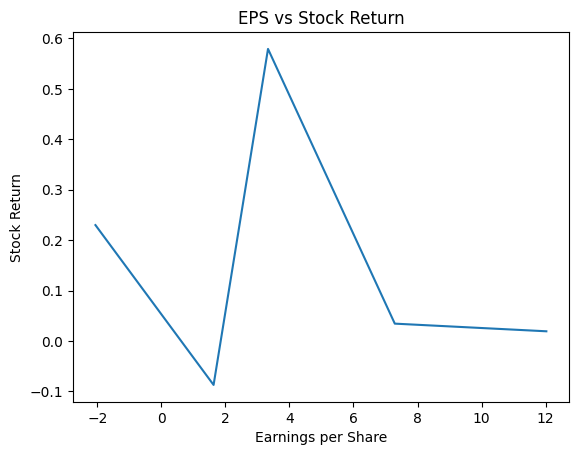

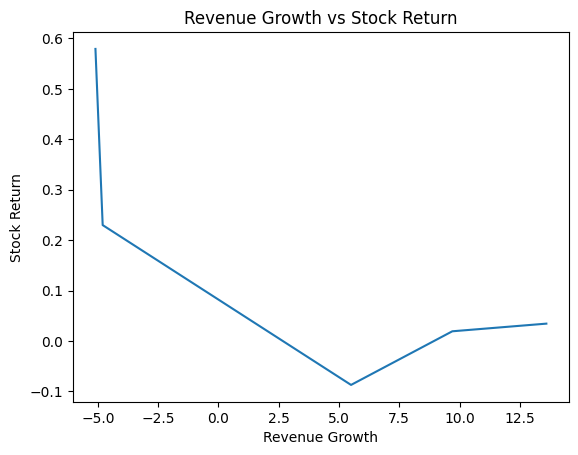

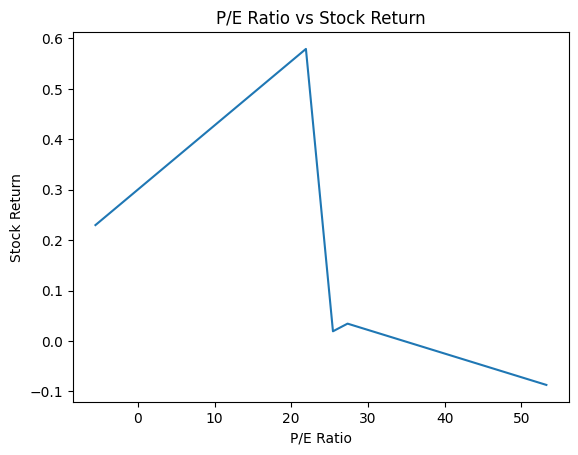

In [91]:
# Consumer Cyclical - Stock Return, EPS, Revenue Growth, P/E Ratio
sns.lineplot(data = cc_data, x = 'Revenue Growth', y = 'Stock Return')
plt.title('Revenue Growth vs Stock Return - Consumer Cyclical')
plt.show()

sns.lineplot(data = cc_data, x = 'Earnings per Share', y = 'Stock Return')
plt.title('EPS vs Stock Return - Consumer Cyclical')
plt.show()

sns.lineplot(data = cc_data, x = 'P/E Ratio', y = 'Stock Return')
plt.title('P/E Ratio vs Stock Return - Consumer Cyclical')
plt.show()

In [92]:
# Create database for averages across sectors

sector_dfs = {
    'Technology': tech_data,
    'Financial Services': fin_data,
    'Communication Services': comm_data,
    'Healthcare': health_data,
    'Consumer Cyclical': cc_data,
    'Industrials': ind_data,
    'Consumer Staples': cs_data
}

sector_means = {
    'Sector': [],
    'Beta':[],
    'Predicted Price Growth Mean': [],
    'Revenue Growth Mean': [],
}

for sector, df in sector_dfs.items():
    sector_means['Sector'].append(sector)
    sector_means['Beta'].append(df['Beta'].mean())
    sector_means['Predicted Price Growth Mean'].append(df['Predicted Price Growth'].mean())
    sector_means['Revenue Growth Mean'].append(df['Revenue Growth'].mean())

In [93]:
sector_means = pd.DataFrame(sector_means)
sector_means

,Sector,Beta,Predicted Price Growth Mean,Revenue Growth Mean
0,Technology,1.420833,49.767038,24.116667
1,Financial Services,1.143250,33.860173,14.825000
2,Communication Services,1.033200,27.930640,12.520000
3,Healthcare,0.369200,17.850601,6.720000
4,Consumer Cyclical,1.173000,24.693255,3.780000
5,Industrials,1.083200,22.365233,15.840000
6,Consumer Staples,0.685400,10.244502,3.440000


Text(0.5, 1.0, 'Beta vs Mean Revenue Growth')

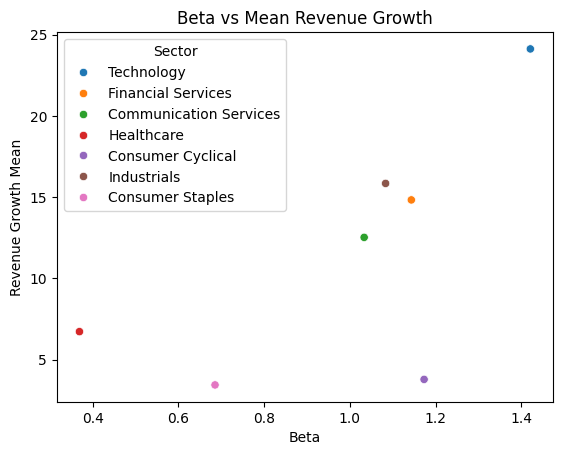

In [94]:
# Fastest Growing Sectors

sns.scatterplot(data = sector_means, x = 'Beta', y = 'Revenue Growth Mean', hue = 'Sector')
plt.title('Beta vs Mean Revenue Growth')

CEO Salary Exploration

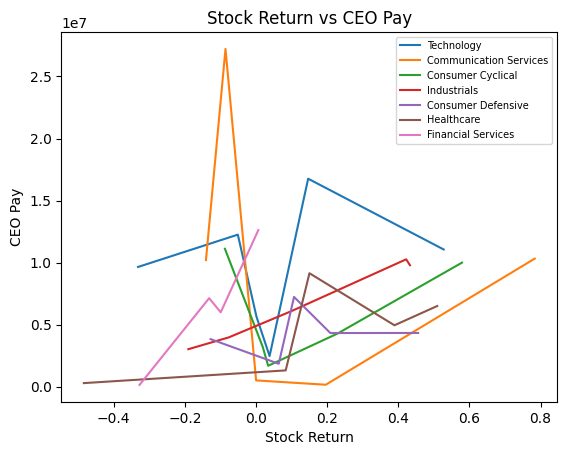

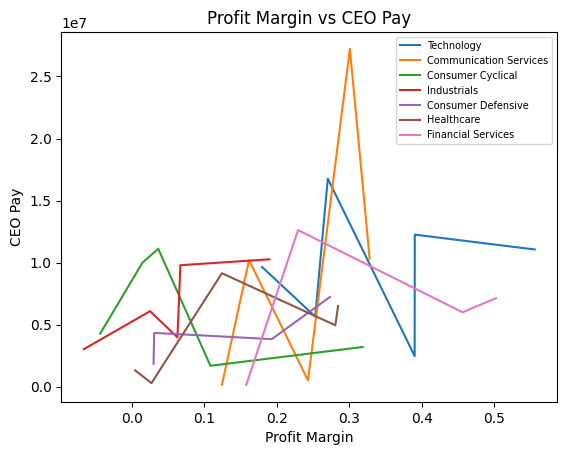

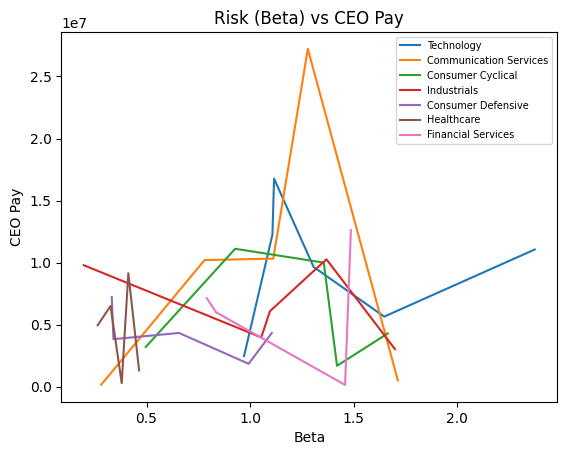

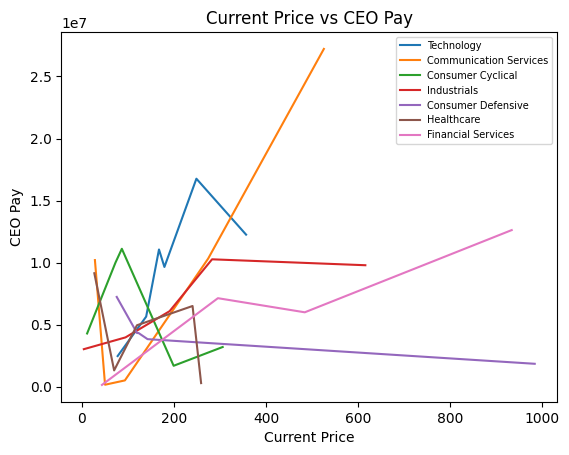

In [95]:
# CEO Pay
sns.lineplot(data = data, x = 'Stock Return', y = 'CEO Pay', hue = 'Sector')
plt.title('Stock Return vs CEO Pay')
plt.legend(fontsize = 7)
plt.show()

sns.lineplot(data = data, x = 'Profit Margin', y = 'CEO Pay', hue = 'Sector')
plt.title('Profit Margin vs CEO Pay')
plt.legend(fontsize = 7)
plt.show()

sns.lineplot(data = data, x = 'Beta', y = 'CEO Pay', hue = 'Sector')
plt.title('Risk (Beta) vs CEO Pay')
plt.legend(fontsize = 7)
plt.show()

sns.lineplot(data = data, x = 'Current Price', y = 'CEO Pay', hue = 'Sector')
plt.title('Current Price vs CEO Pay')
plt.legend(fontsize = 7)
plt.show()

In [96]:
# Industrial industry seems to have the most obvious and consistant linear relationship in all graphs
  # CEO Pay is positively correlated with stock return and profit margin, and negatively correlated with risk

# Is this trend applicable to the rest of the sector or is my sample size just too small?
# Are there non-performance traits that correlate?

In [97]:
# Explore Industrial Sector

industrial_sector = yf.Sector('industrials').top_companies
industrial_sector = industrial_sector.reset_index()

ind_data = []

for symbol in industrial_sector['symbol']:
    ticker_object = yf.Ticker(symbol)

    # Basic Info
    company_name = ticker_object.info['longName']

    # CEO Pay
    position = ticker_object.info['companyOfficers'][0]
    if 'totalPay' in position:
      pay = position['totalPay']
    else:
      pay = 'Unknown'

    # Profit Margin
    profit_margin = ticker_object.info['profitMargins']

    # Current Price
    current_price = ticker_object.info['currentPrice']

    # Company Size
    size = ticker_object.info['fullTimeEmployees']
    mkcap = ticker_object.info['marketCap']

    ind_data.append({
      'Company':company_name,
      'CEO Pay':pay,
      # 'Stock Return':stock_return,
      # 'Beta':beta,
      'Current Price':current_price,
      # 'Target Price':tg_price,
      'Profit Margin':profit_margin,
      'Company Size':size,
      'Market Cap':mkcap
      # 'Predicted Price Growth':price_growth,
      # 'Revenue Growth':revenue_growth
        })

ind_data = pd.DataFrame(ind_data)

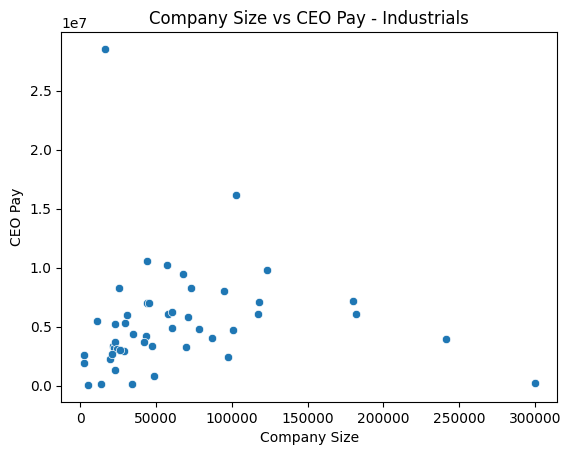

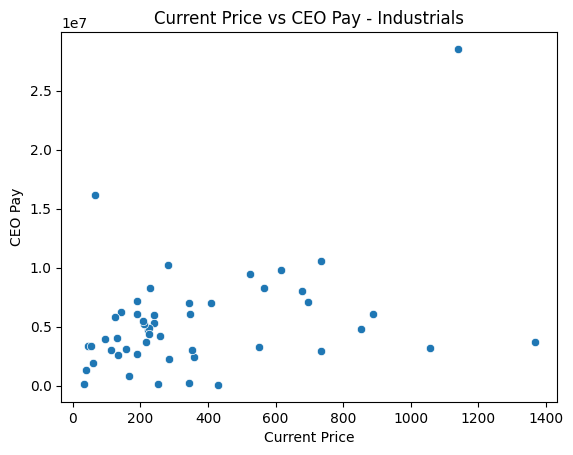

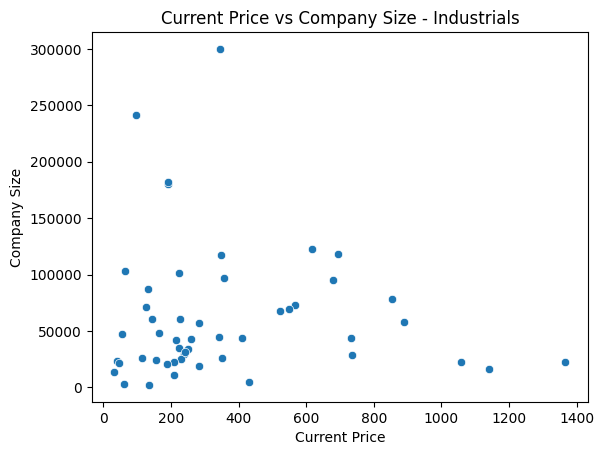

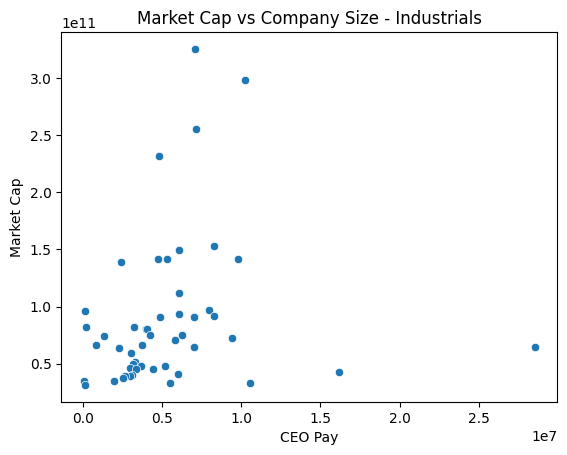

In [98]:
sns.scatterplot(data = ind_data, x = 'Company Size', y = 'CEO Pay')
plt.title('Company Size vs CEO Pay - Industrials')
plt.show()

sns.scatterplot(data = ind_data, x = 'Current Price', y = 'CEO Pay')
plt.title('Current Price vs CEO Pay - Industrials')
plt.show()

sns.scatterplot(data = ind_data, x = 'Current Price', y = 'Company Size')
plt.title('Current Price vs Company Size - Industrials')
plt.show()

sns.scatterplot(data = ind_data, x = 'CEO Pay', y = 'Market Cap')
plt.title('Market Cap vs Company Size - Industrials')
plt.show()